# AWG to Alazar heterodyne tomography validation

This notebook validates the room-temperature measurement chain:

1. The AWG5208 emits `envelope(t) * cos(2*pi*fc*t + phase)`.
2. An AWG marker triggers the ATS9371.
3. Alazar records are digitally downconverted.
4. Every shot is projected onto one boxcar or Gaussian temporal mode.
5. Reference and signal IQ clouds are normalized.
6. An ideal-heterodyne maximum-likelihood density matrix and Wigner function
   are reconstructed.

Important limitation: an AWG produces a classical coherent microwave field.
The room-temperature reference is electronic noise, not calibrated vacuum
noise. Therefore the reconstructed state is a pipeline validation, not an
absolute quantum tomography result, and it should not show trustworthy Wigner
negativity. After the cryogenic chain is ready, replace the reference and
amplitude calibration while keeping the same acquisition and analysis path.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from QAWG import AWGAlazar
from QAWG.awg5200 import delay, gaussian_square_ns, waveform
from QAWG.tomography import (
    coherent_density_matrix,
    heterodyne_ml_density_matrix,
    normalize_heterodyne_reference,
    project_temporal_mode,
    temporal_mode_weights,
    wigner_function,
)

## Hardware and waveform parameters

In [2]:
AWG_RESOURCE = "TCPIP0::192.168.10.171::inst0::INSTR"

AWG_SAMPLE_RATE_HZ = 2.5e9
ALAZAR_SAMPLE_RATE_HZ = 1e9
FC_HZ = 50e6
ADC_CHANNEL = "CHA"

AWG_SIGNAL_CHANNEL = 3
AWG_MARKER_CHANNEL = 1
CHANNEL_AMPLITUDE_VPP = 0.5
PULSE_SHAPE = "exponential"  # "exponential" or "flat_top"
PULSE_PEAK_VOLTS = 0.0002
PULSE_DURATION_NS = 1250
EDGE_SIGMA_NS = 40
EMISSION_T1_NS = 250
AWG_LEADING_DELAY_NS = 500
AWG_TOTAL_DURATION_NS = 3000

ACQUIRE_WINDOW_NS = 1400
TRIGGER_DELAY_NS = 0
MODE_START_NS = 0
MODE_STOP_NS = 1250
MODE_KIND = "exponential"  # "exponential", "boxcar", or "gaussian"
GAUSSIAN_SIGMA_NS = 220

NUM_REFERENCE_SHOTS = 5000
NUM_SIGNAL_SHOTS = 5000
FOCK_CUTOFF = 8
ML_ITERATIONS = 200
WIGNER_LIMIT = 2.0
WIGNER_POINTS = 81

ALAZAR_TIMEOUT_MS = 60_000

## Connect and configure

In [3]:
experiment = AWGAlazar.connect(
    AWG_RESOURCE,
    awg_sample_rate_hz=AWG_SAMPLE_RATE_HZ,
    alazar_sample_rate_hz=ALAZAR_SAMPLE_RATE_HZ,
    tone_frequency_hz=FC_HZ,
    trigger_delay_s=TRIGGER_DELAY_NS * 1e-9,
    acquire_window_ns=ACQUIRE_WINDOW_NS,
    integrate_window_ns=(MODE_START_NS, MODE_STOP_NS),
    adc_channel=ADC_CHANNEL,
    timeout_ms=ALAZAR_TIMEOUT_MS,
    use_external_10mhz_reference=True,
)

print("AWG:", experiment.awg.identify())
print("ADC channel:", experiment.adc_channel_name)
print("Record samples:", experiment.acquire_window_cycles)

AWG: TEKTRONIX,AWG5208,B030598,FV:6.6.0131.0
ADC channel: CHA
Record samples: 1408


## Upload `waveform * fc` and aligned marker

The marker remains active when the analog signal channel is disabled. This
allows reference and signal records to use identical trigger timing.

In [4]:
if PULSE_SHAPE == "exponential":
    pulse_samples = experiment.ns2cycles(PULSE_DURATION_NS, inst="dac")
    pulse_time_ns = (
        np.arange(pulse_samples) / experiment.awg_sample_rate_hz * 1e9
    )
    # Field amplitude decays as exp(-t / (2*T1)); power decays as exp(-t / T1).
    envelope = PULSE_PEAK_VOLTS * np.exp(
        -pulse_time_ns / (2.0 * EMISSION_T1_NS)
    )
elif PULSE_SHAPE == "flat_top":
    envelope = gaussian_square_ns(
        duration_ns=PULSE_DURATION_NS,
        sample_rate_hz=experiment.awg_sample_rate_hz,
        edge_sigma_ns=EDGE_SIGMA_NS,
        amplitude_volts=PULSE_PEAK_VOLTS,
    )
else:
    raise ValueError("PULSE_SHAPE must be 'exponential' or 'flat_top'")

carrier_waveform = waveform(
    envelope,
    fc=FC_HZ,
    ch=AWG_SIGNAL_CHANNEL,
    phase_radians=0.0,
    name="tomography_carrier",
)
timeline = delay(AWG_LEADING_DELAY_NS * 1e-9) / carrier_waveform
uploaded = experiment.awg.upload_timeline(
    timeline,
    amplitude_vpp={AWG_SIGNAL_CHANNEL: CHANNEL_AMPLITUDE_VPP},
    total_duration_s=AWG_TOTAL_DURATION_NS * 1e-9,
)
marker_name = experiment.awg.marker(
    waveform_ch=AWG_SIGNAL_CHANNEL,
    marker_ch=AWG_MARKER_CHANNEL,
    marker_number=1,
    low_volts=0.0,
    high_volts=1.2,
    amplitude_vpp=CHANNEL_AMPLITUDE_VPP,
)

print("Signal asset:", uploaded[AWG_SIGNAL_CHANNEL])
print("Marker asset:", marker_name)
print("Pulse shape:", PULSE_SHAPE)
if PULSE_SHAPE == "exponential":
    print("Simulated emission T1:", EMISSION_T1_NS, "ns")
print("AWG error:", experiment.awg.error())

Signal asset: tomography_carrier
Marker asset: marker_ch1_for_ch3
Pulse shape: exponential
Simulated emission T1: 250 ns
AWG error: 0,"No error"


## Acquire reference and signal shots

In [5]:
# Reference: keep the marker running, disable only the analog carrier output.
experiment.awg.set_output(AWG_SIGNAL_CHANNEL, False)
_, reference_baseband = experiment.acquire(NUM_REFERENCE_SHOTS)
reference_records = experiment.last_records_volts.copy()

# Signal: same waveform and marker timing, analog carrier enabled.
experiment.awg.set_output(AWG_SIGNAL_CHANNEL, True)
_, signal_baseband = experiment.acquire(NUM_SIGNAL_SHOTS)
signal_records = experiment.last_records_volts.copy()

print("Reference baseband:", reference_baseband.shape)
print("Signal baseband:", signal_baseband.shape)
print("Signal capture diagnostics:")
for key, value in experiment.capture_diagnostics().items():
    print(f"  {key}: {value}")

Reference baseband: (5000, 1408)
Signal baseband: (5000, 1408)
Signal capture diagnostics:
  adc_channel: CHA
  adc_bits: 12
  adc_lsb_mv: 0.1953125
  raw_code_min: 32448
  raw_code_max: 33040
  mean_offset_mv: -0.4919369229403408
  average_peak_to_peak_mv: 0.30511718749999933
  shot_noise_std_mv: 0.7283271158444159


## Inspect raw and coherently averaged records

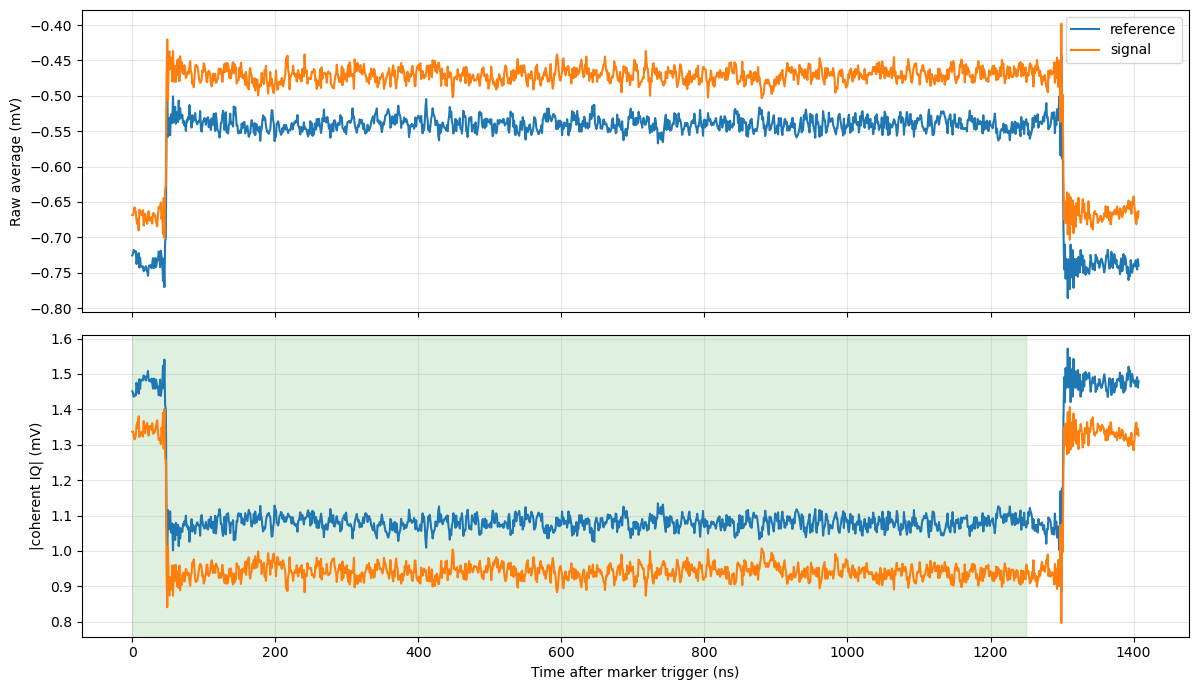

In [6]:
time_ns = np.arange(signal_records.shape[1]) / ALAZAR_SAMPLE_RATE_HZ * 1e9

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(time_ns, np.mean(reference_records, axis=0) * 1e3, label="reference")
axes[0].plot(time_ns, np.mean(signal_records, axis=0) * 1e3, label="signal")
axes[0].set_ylabel("Raw average (mV)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_ns, np.abs(np.mean(reference_baseband, axis=0)) * 1e3)
axes[1].plot(time_ns, np.abs(np.mean(signal_baseband, axis=0)) * 1e3)
axes[1].axvspan(MODE_START_NS, MODE_STOP_NS, color="tab:green", alpha=0.15)
axes[1].set_xlabel("Time after marker trigger (ns)")
axes[1].set_ylabel("|coherent IQ| (mV)")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Temporal-mode projection

In [7]:
mode_start = experiment.ns2cycles(MODE_START_NS, inst="adc")
mode_stop = experiment.ns2cycles(MODE_STOP_NS, inst="adc")
mode_samples = mode_stop - mode_start
sigma_samples = GAUSSIAN_SIGMA_NS * 1e-9 * ALAZAR_SAMPLE_RATE_HZ
decay_samples = EMISSION_T1_NS * 1e-9 * ALAZAR_SAMPLE_RATE_HZ

mode = temporal_mode_weights(
    mode_samples,
    kind=MODE_KIND,
    sigma_samples=sigma_samples if MODE_KIND == "gaussian" else None,
    decay_samples=decay_samples if MODE_KIND == "exponential" else None,
)
reference_mode_volts = project_temporal_mode(
    reference_baseband,
    mode,
    start_sample=mode_start,
)
signal_mode_volts = project_temporal_mode(
    signal_baseband,
    mode,
    start_sample=mode_start,
)

print("Reference mean:", np.mean(reference_mode_volts))
print("Signal mean:", np.mean(signal_mode_volts))
print("Electrical SNR:", abs(np.mean(signal_mode_volts) - np.mean(reference_mode_volts))
      / np.std(reference_mode_volts))

Reference mean: (-8.99864038378815e-05+0.0003335660696194857j)
Signal mean: (-8.945039298070594e-05+0.00032851852324896957j)
Electrical SNR: 0.002626454626429763


## Reference normalization

The reference is centered and scaled so
\(\langle |\alpha|^2\rangle_{\rm ref}=1\), matching the ideal vacuum
heterodyne convention. At room temperature this is a convenient numerical
normalization only. For quantum tomography, replace it with a calibrated
system gain/noise measurement.

IQ offset (mode volts): (-8.99864038378815e-05+0.0003335660696194857j)
IQ scale (mode volts / alpha): 0.001932615420990024
Reference <|alpha|^2>: 1.0
Signal mean alpha: (0.0002773499845618453-0.0026117696856265823j)
Reference quadrature variances: 0.4982415806704953 0.5017584193295047


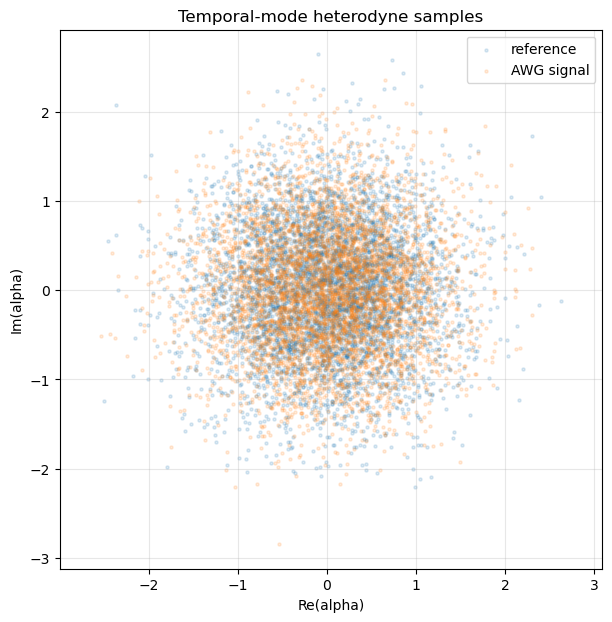

In [8]:
alpha_reference, (alpha_signal,), iq_offset, iq_scale = (
    normalize_heterodyne_reference(reference_mode_volts, signal_mode_volts)
)

print("IQ offset (mode volts):", iq_offset)
print("IQ scale (mode volts / alpha):", iq_scale)
print("Reference <|alpha|^2>:", np.mean(np.abs(alpha_reference) ** 2))
print("Signal mean alpha:", np.mean(alpha_signal))
print("Reference quadrature variances:",
      np.var(alpha_reference.real), np.var(alpha_reference.imag))

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(alpha_reference.real, alpha_reference.imag, s=5, alpha=0.15, label="reference")
ax.scatter(alpha_signal.real, alpha_signal.imag, s=5, alpha=0.15, label="AWG signal")
ax.set_xlabel("Re(alpha)")
ax.set_ylabel("Im(alpha)")
ax.set_title("Temporal-mode heterodyne samples")
ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Maximum-likelihood density matrix

trace(rho): (0.9999999999999999+0j)
minimum eigenvalue: -3.173520195121367e-19
purity: 0.9762088172595119
overlap with coherent state at mean alpha: 0.9866322112394003
photon populations: [9.86586977e-01 9.11903938e-03 3.16385462e-03 1.56732750e-04
 5.73714537e-04 3.13430591e-04 1.63611333e-05 6.98904547e-05]
mean photon number <n>: 0.020366357946870584
g2(0): 57.493211655914784
population at Fock cutoff: 6.989045470295543e-05


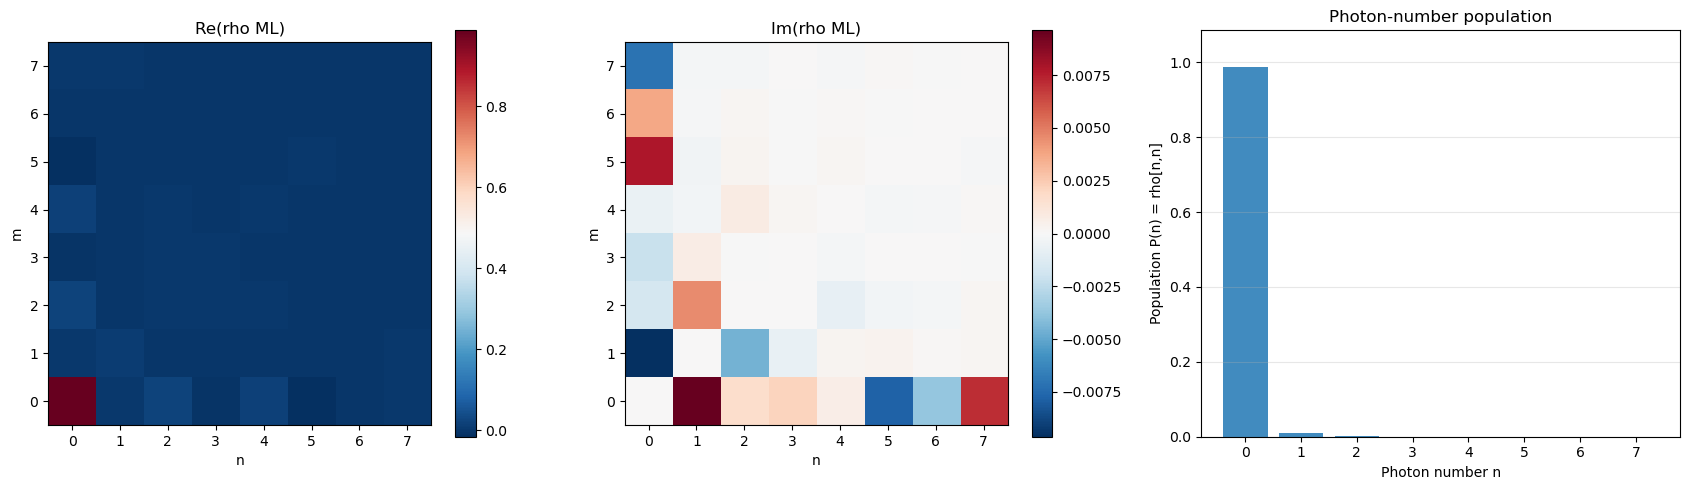

In [9]:
rho_ml = heterodyne_ml_density_matrix(
    alpha_signal,
    cutoff=FOCK_CUTOFF,
    iterations=ML_ITERATIONS,
    dilution=0.5,
)
alpha_mean = np.mean(alpha_signal)
rho_coherent = coherent_density_matrix(alpha_mean, cutoff=FOCK_CUTOFF)
fidelity_to_coherent = float(np.real(np.trace(rho_ml @ rho_coherent)))
purity = float(np.real(np.trace(rho_ml @ rho_ml)))

print("trace(rho):", np.trace(rho_ml))
print("minimum eigenvalue:", np.min(np.linalg.eigvalsh(rho_ml)))
print("purity:", purity)
print("overlap with coherent state at mean alpha:", fidelity_to_coherent)
photon_population = np.maximum(np.real(np.diag(rho_ml)), 0.0)
photon_population /= np.sum(photon_population)
photon_number = np.arange(FOCK_CUTOFF)
mean_photon_number = float(np.sum(photon_number * photon_population))
factorial_moment_2 = float(
    np.sum(photon_number * (photon_number - 1) * photon_population)
)
g2_zero = (
    factorial_moment_2 / mean_photon_number**2
    if mean_photon_number > 0
    else np.nan
)

print("photon populations:", photon_population)
print("mean photon number <n>:", mean_photon_number)
print("g2(0):", g2_zero)
print("population at Fock cutoff:", photon_population[-1])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
image0 = axes[0].imshow(np.real(rho_ml), origin="lower", cmap="RdBu_r")
axes[0].set_title("Re(rho ML)")
axes[0].set_xlabel("n")
axes[0].set_ylabel("m")
plt.colorbar(image0, ax=axes[0])
image1 = axes[1].imshow(np.imag(rho_ml), origin="lower", cmap="RdBu_r")
axes[1].set_title("Im(rho ML)")
axes[1].set_xlabel("n")
axes[1].set_ylabel("m")
plt.colorbar(image1, ax=axes[1])

axes[2].bar(photon_number, photon_population, color="tab:blue", alpha=0.85)
axes[2].set_xticks(photon_number)
axes[2].set_ylim(0, max(1.0, 1.1 * np.max(photon_population)))
axes[2].set_xlabel("Photon number n")
axes[2].set_ylabel("Population P(n) = rho[n,n]")
axes[2].set_title("Photon-number population")
axes[2].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

if photon_population[-1] > 0.01:
    print(
        "WARNING: population at the highest retained Fock state exceeds 1%. "
        "Increase FOCK_CUTOFF before trusting the reconstruction."
    )

## Wigner function calculated from the reconstructed density matrix

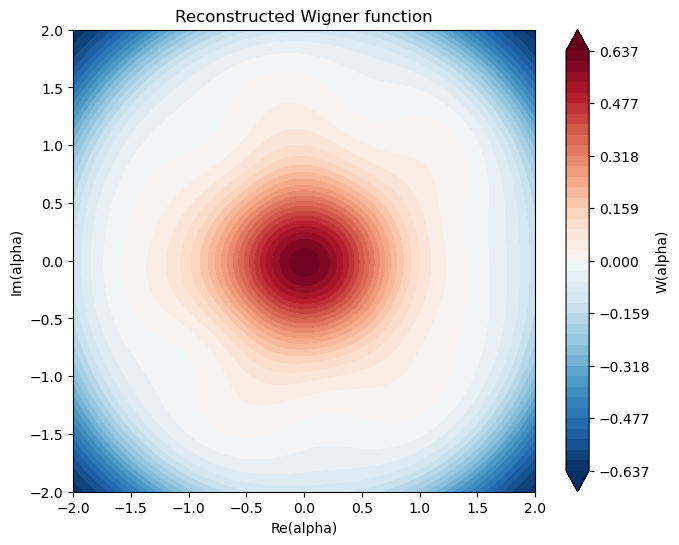

Wigner minimum: -0.6219565586361291
Wigner integral estimate: -0.3510689700850133
Interpret only the central region. Rings near the plot boundary can be finite-Fock-cutoff artifacts rather than physical photon populations.


In [10]:
axis = np.linspace(-WIGNER_LIMIT, WIGNER_LIMIT, WIGNER_POINTS)
wigner = wigner_function(rho_ml, axis, axis)

fig, ax = plt.subplots(figsize=(8, 6))
levels = np.linspace(-2 / np.pi, 2 / np.pi, 41)
contour = ax.contourf(axis, axis, wigner, levels=levels, cmap="RdBu_r", extend="both")
ax.set_xlabel("Re(alpha)")
ax.set_ylabel("Im(alpha)")
ax.set_title("Reconstructed Wigner function")
ax.set_aspect("equal")
plt.colorbar(contour, ax=ax, label="W(alpha)")
plt.show()

print("Wigner minimum:", np.min(wigner))
print("Wigner integral estimate:",
      np.sum(wigner) * (axis[1] - axis[0]) ** 2)
print(
    "Interpret only the central region. Rings near the plot boundary can be "
    "finite-Fock-cutoff artifacts rather than physical photon populations."
)

## Save acquisition and reconstruction

In [11]:
np.savez_compressed(
    "tomography_capture.npz",
    reference_records=reference_records,
    signal_records=signal_records,
    reference_mode_volts=reference_mode_volts,
    signal_mode_volts=signal_mode_volts,
    alpha_reference=alpha_reference,
    alpha_signal=alpha_signal,
    temporal_mode=mode,
    density_matrix=rho_ml,
    wigner_axis=axis,
    wigner=wigner,
    fc_hz=FC_HZ,
    sample_rate_hz=ALAZAR_SAMPLE_RATE_HZ,
)
print("Saved tomography_capture.npz")

Saved tomography_capture.npz


## Close hardware session

In [ ]:
experiment.awg.set_output(AWG_SIGNAL_CHANNEL, False)
experiment.close()
print("AWG VISA session closed")